# SAM3 Building Identifier — Visualization & Evaluation

Visualizes SAM3 predictions vs. xView2 ground truth and computes IoU-based metrics.

**Prediction formats supported automatically:**
- *SAM3_Claude* new format: `predictions/{stem}_prediction.json` with `instances[]`
- *Notebook* old format: `labels/{stem}_prediction.json` with `features.xy[].wkt`

**Ground truth format:** `{gt_dir}/{stem}.json` with `features.xy[].wkt`

In [1]:
# ── Cell 1: Paths — edit these ──────────────────────────────────────────────

# Root output directory from the SAM3_Claude pipeline
# (contains predictions/, masks/, annotations/ sub-folders)
PRED_DIR  = "/media/data/building_instance_tamu/sam3_claude/test"

# xView2 ground-truth labels directory
GT_DIR    = "/media/data/building_instance_tamu/test/labels"

# Original images directory (leave as None to skip image backgrounds)
IMAGE_DIR = "/media/data/building_instance_tamu/test/images"

# IoU threshold for TP/FP/FN assignment
IOU_THRESHOLD = 0.5

In [2]:
# ── Cell 2: Imports ──────────────────────────────────────────────────────────
import json
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection
import matplotlib.colors as mcolors
from PIL import Image
from shapely import wkt as shapely_wkt
from shapely.geometry import Polygon, box
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


In [3]:
# ── Cell 3: Parsers ──────────────────────────────────────────────────────────
# Each parser returns a list of dicts:
#   {'polygon': Shapely Polygon, 'bbox': (x1,y1,x2,y2), 'confidence': float|None}

def _polygon_from_coords(coords):
    """Build a Shapely Polygon from [[x,y],...] list. Returns None if invalid."""
    if len(coords) < 3:
        return None
    try:
        p = Polygon(coords)
        if not p.is_valid:
            p = p.buffer(0)
        return p if not p.is_empty else None
    except Exception:
        return None


def _polygon_from_wkt(wkt_str):
    """Parse a WKT string to a Shapely Polygon. Returns None on failure."""
    try:
        p = shapely_wkt.loads(wkt_str)
        if not p.is_valid:
            p = p.buffer(0)
        return p if not p.is_empty else None
    except Exception:
        return None


def _bbox_from_polygon(poly):
    if poly is None or poly.is_empty:
        return None
    minx, miny, maxx, maxy = poly.bounds
    return (minx, miny, maxx, maxy)


def parse_gt(gt_path: Path) -> List[dict]:
    """Parse a ground-truth JSON file. Returns list of instance dicts."""
    if not gt_path.exists():
        return []
    with open(gt_path) as f:
        doc = json.load(f)

    features = doc.get("features", {}).get("xy", [])
    instances = []
    for feat in features:
        props = feat.get("properties", {})
        if props.get("feature_type") != "building":
            continue
        poly = _polygon_from_wkt(feat.get("wkt", ""))
        if poly is None:
            continue
        instances.append({
            "polygon": poly,
            "bbox": _bbox_from_polygon(poly),
            "confidence": None,
        })
    return instances


def parse_pred_new(pred_path: Path) -> List[dict]:
    """Parse SAM3_Claude 'new' format: top-level 'instances' list."""
    with open(pred_path) as f:
        doc = json.load(f)
    instances = []
    for inst in doc.get("instances", []):
        coords = inst.get("polygon", [])
        poly = _polygon_from_coords(coords)
        if poly is None:
            bbox_raw = inst.get("bbox_xyxy")
            if bbox_raw and len(bbox_raw) == 4:
                poly = box(*bbox_raw)
        if poly is None:
            continue
        instances.append({
            "polygon": poly,
            "bbox": tuple(inst["bbox_xyxy"]) if inst.get("bbox_xyxy") else _bbox_from_polygon(poly),
            "confidence": inst.get("confidence"),
        })
    return instances


def parse_pred_old(pred_path: Path) -> List[dict]:
    """Parse notebook 'old' format: features.xy[].wkt with optional prob."""
    with open(pred_path) as f:
        doc = json.load(f)
    features = doc.get("features", {}).get("xy", [])
    instances = []
    for feat in features:
        poly = _polygon_from_wkt(feat.get("wkt", ""))
        if poly is None:
            continue
        conf = feat.get("properties", {}).get("prob", None)
        instances.append({
            "polygon": poly,
            "bbox": _bbox_from_polygon(poly),
            "confidence": conf,
        })
    return instances


def parse_pred(pred_path: Path) -> Tuple[List[dict], str]:
    """Auto-detect and parse a prediction file. Returns (instances, format_name)."""
    with open(pred_path) as f:
        doc = json.load(f)
    if "instances" in doc:
        return parse_pred_new(pred_path), "sam3_claude_new"
    elif "features" in doc:
        return parse_pred_old(pred_path), "notebook_old"
    else:
        return [], "unknown"


print("Parsers defined.")

Parsers defined.


In [4]:
# ── Cell 4: Discover prediction files + detect format ────────────────────────

pred_root = Path(PRED_DIR)
gt_root   = Path(GT_DIR)

# Look for prediction files: new format in predictions/ subdir, else labels/ subdir
def _find_pred_files(root: Path) -> Tuple[List[Path], str]:
    for subdir in ("predictions", "labels", ""):
        search_dir = root / subdir if subdir else root
        files = sorted(search_dir.glob("*_prediction.json"))
        if files:
            return files, str(search_dir)
    return [], str(root)

pred_files, pred_search_dir = _find_pred_files(pred_root)
print(f"Prediction dir   : {pred_search_dir}")
print(f"Prediction files : {len(pred_files)}")

# Detect format from first file
if pred_files:
    _, fmt = parse_pred(pred_files[0])
    print(f"Prediction format: {fmt}")
else:
    fmt = None
    print("WARNING: No prediction files found.")

# Build stem → pred_path index
# New format: {stem}_prediction.json → stem has no _prediction suffix
def _stem_from_pred(p: Path) -> str:
    return p.stem.replace("_prediction", "")

pred_index: Dict[str, Path] = {_stem_from_pred(p): p for p in pred_files}

# Build GT index: exact filename without extension
gt_files = sorted(gt_root.glob("*.json")) if gt_root.exists() else []
gt_index: Dict[str, Path] = {p.stem: p for p in gt_files}
print(f"GT dir           : {gt_root}")
print(f"GT files         : {len(gt_files)}")

# Paired stems (have both pred and GT)
paired_stems = sorted(set(pred_index) & set(gt_index))
pred_only    = sorted(set(pred_index) - set(gt_index))
gt_only      = sorted(set(gt_index)   - set(pred_index))

print(f"\nPaired (pred + GT): {len(paired_stems)}")
print(f"Pred only (no GT) : {len(pred_only)}")
print(f"GT only (no pred) : {len(gt_only)}")
if paired_stems:
    print(f"\nExample paired stems:")
    for s in paired_stems[:5]:
        print(f"  {s}")

Prediction dir   : /media/data/building_instance_tamu/sam3_claude/test/predictions
Prediction files : 933
Prediction format: sam3_claude_new
GT dir           : /media/data/building_instance_tamu/test/labels
GT files         : 1866

Paired (pred + GT): 933
Pred only (no GT) : 0
GT only (no pred) : 933

Example paired stems:
  guatemala-volcano_00000003_pre_disaster
  guatemala-volcano_00000005_pre_disaster
  guatemala-volcano_00000009_pre_disaster
  guatemala-volcano_00000011_pre_disaster
  guatemala-volcano_00000021_pre_disaster


In [5]:
# ── Cell 5: Inspect one pair (format sanity check) ───────────────────────────

if not paired_stems:
    print("No paired images — skipping format inspection.")
else:
    stem = paired_stems[0]
    gt_inst  = parse_gt(gt_index[stem])
    pred_inst, _ = parse_pred(pred_index[stem])

    print(f"Image: {stem}")
    print(f"  GT instances   : {len(gt_inst)}")
    if gt_inst:
        p = gt_inst[0]['polygon']
        print(f"  GT[0] area     : {p.area:.1f} px²   bounds: {[round(x) for x in p.bounds]}")

    print(f"  Pred instances : {len(pred_inst)}")
    if pred_inst:
        p = pred_inst[0]['polygon']
        print(f"  Pred[0] area   : {p.area:.1f} px²   conf: {pred_inst[0]['confidence']}")
        print(f"  Pred[0] bounds : {[round(x) for x in p.bounds]}")

Image: guatemala-volcano_00000003_pre_disaster
  GT instances   : 3
  GT[0] area     : 1924.1 px²   bounds: [435, 87, 491, 135]
  Pred instances : 3
  Pred[0] area   : 2128.0 px²   conf: 0.8094
  Pred[0] bounds : [429, 83, 495, 134]


In [6]:
# ── Cell 6: IoU helpers ───────────────────────────────────────────────────────

def polygon_iou(a: Polygon, b: Polygon) -> float:
    """Intersection-over-Union for two Shapely polygons."""
    if a is None or b is None or a.is_empty or b.is_empty:
        return 0.0
    try:
        inter = a.intersection(b).area
        union = a.union(b).area
        return inter / union if union > 0 else 0.0
    except Exception:
        return 0.0


def bbox_iou(a, b) -> float:
    """IoU for two (x1,y1,x2,y2) tuples. Fallback when polygons unavailable."""
    if a is None or b is None:
        return 0.0
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    a_area = (ax2 - ax1) * (ay2 - ay1)
    b_area = (bx2 - bx1) * (by2 - by1)
    union = a_area + b_area - inter
    return inter / union if union > 0 else 0.0


def compute_instance_iou(p, g) -> float:
    """Compute IoU between one pred and one GT. Prefer polygon, fallback to bbox."""
    if p.get('polygon') and g.get('polygon'):
        return polygon_iou(p['polygon'], g['polygon'])
    return bbox_iou(p.get('bbox'), g.get('bbox'))


def match_predictions(
    pred_inst: List[dict],
    gt_inst: List[dict],
    iou_thresh: float = 0.5,
) -> dict:
    """
    Greedy matching of predictions to GT instances at a given IoU threshold.
    Preds sorted by confidence (descending); each GT matched at most once.

    Returns dict with:
      tp, fp, fn, iou_per_tp, matched_pairs [(pred_idx, gt_idx, iou)]
    """
    # Sort preds by confidence descending (None → 0.0)
    sorted_preds = sorted(
        enumerate(pred_inst),
        key=lambda x: x[1].get('confidence') or 0.0,
        reverse=True,
    )

    matched_gt = set()
    tp_iou = []
    matched_pairs = []  # (pred_idx, gt_idx, iou)
    fp_indices = []

    for pred_idx, p in sorted_preds:
        best_iou, best_gt_idx = 0.0, -1
        for gt_idx, g in enumerate(gt_inst):
            if gt_idx in matched_gt:
                continue
            iou = compute_instance_iou(p, g)
            if iou > best_iou:
                best_iou, best_gt_idx = iou, gt_idx

        if best_iou >= iou_thresh and best_gt_idx >= 0:
            matched_gt.add(best_gt_idx)
            tp_iou.append(best_iou)
            matched_pairs.append((pred_idx, best_gt_idx, best_iou))
        else:
            fp_indices.append(pred_idx)

    tp = len(matched_pairs)
    fp = len(pred_inst) - tp
    fn = len(gt_inst) - tp

    return {
        'tp': tp, 'fp': fp, 'fn': fn,
        'iou_per_tp': tp_iou,
        'matched_pairs': matched_pairs,
        'fp_pred_indices': fp_indices,
        'fn_gt_indices': [i for i in range(len(gt_inst)) if i not in matched_gt],
    }


def compute_metrics(tp, fp, fn, iou_list) -> dict:
    prec  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec   = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1    = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    miou  = float(np.mean(iou_list)) if iou_list else 0.0
    return {'precision': prec, 'recall': rec, 'f1': f1, 'mean_iou_tp': miou}


print("IoU helpers defined.")

IoU helpers defined.


In [7]:
# ── Cell 7: Visualization helper ─────────────────────────────────────────────

GT_COLOR   = '#00ff00'   # green
PRED_COLOR = '#ff6600'   # orange
TP_COLOR   = '#00aaff'   # blue  (matched prediction)
FP_COLOR   = '#ff0000'   # red   (false positive)
FN_COLOR   = '#ffff00'   # yellow (missed GT)


def _draw_instances(ax, instances, color, alpha=0.35, label=None):
    """Draw filled + outlined polygons (or bbox rectangles) on an axes."""
    for i, inst in enumerate(instances):
        poly = inst.get('polygon')
        if poly is not None and not poly.is_empty:
            xs, ys = poly.exterior.xy
            ax.fill(xs, ys, color=color, alpha=alpha)
            ax.plot(xs, ys, color=color, linewidth=1.5)
        elif inst.get('bbox'):
            x1, y1, x2, y2 = inst['bbox']
            rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  edgecolor=color, facecolor=color,
                                  linewidth=1.5, alpha=alpha)
            ax.add_patch(rect)


def _load_image_arr(stem: str) -> Optional[np.ndarray]:
    """Try to load the background image for a given stem."""
    if IMAGE_DIR is None:
        return None
    img_dir = Path(IMAGE_DIR)
    for ext in (".png", ".jpg", ".jpeg", ".tif"):
        p = img_dir / f"{stem}{ext}"
        if p.exists():
            return np.array(Image.open(p).convert("RGB"))
    return None


def visualize_single(
    stem: str,
    pred_inst: List[dict],
    gt_inst: List[dict],
    match_result: Optional[dict] = None,
    iou_thresh: float = IOU_THRESHOLD,
):
    """3-panel visualization: GT | Prediction | Overlay with TP/FP/FN colours."""
    img_arr = _load_image_arr(stem)
    H = W = 1024  # default; will be overridden if image loaded
    if img_arr is not None:
        H, W = img_arr.shape[:2]

    def _bg(ax):
        if img_arr is not None:
            ax.imshow(img_arr)
        else:
            ax.set_facecolor('#1a1a1a')
            ax.set_xlim(0, W); ax.set_ylim(H, 0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(stem, fontsize=11, y=1.01)

    # Panel 1: Ground truth
    _bg(axes[0])
    _draw_instances(axes[0], gt_inst, GT_COLOR)
    axes[0].set_title(f"Ground Truth ({len(gt_inst)} buildings)", fontsize=10)
    axes[0].axis('off')

    # Panel 2: Predictions
    _bg(axes[1])
    _draw_instances(axes[1], pred_inst, PRED_COLOR)
    axes[1].set_title(f"Predictions ({len(pred_inst)} detections)", fontsize=10)
    axes[1].axis('off')

    # Panel 3: Overlay with TP/FP/FN
    _bg(axes[2])
    if match_result:
        tp_pred_idxs = {pi for pi, _, _ in match_result['matched_pairs']}
        tp_gt_idxs   = {gi for _, gi, _ in match_result['matched_pairs']}
        # TP predictions = blue
        _draw_instances(axes[2], [pred_inst[i] for i in tp_pred_idxs], TP_COLOR, alpha=0.4)
        # FP predictions = red
        _draw_instances(axes[2], [pred_inst[i] for i in match_result['fp_pred_indices']], FP_COLOR, alpha=0.4)
        # FN ground truth = yellow
        _draw_instances(axes[2], [gt_inst[i] for i in match_result['fn_gt_indices']], FN_COLOR, alpha=0.4)

        tp, fp, fn = match_result['tp'], match_result['fp'], match_result['fn']
        m = compute_metrics(tp, fp, fn, match_result['iou_per_tp'])
        title = (
            f"Overlay   TP={tp}  FP={fp}  FN={fn}\n"
            f"P={m['precision']:.2f}  R={m['recall']:.2f}  "
            f"F1={m['f1']:.2f}  mIoU={m['mean_iou_tp']:.2f}"
        )
        handles = [
            mpatches.Patch(color=TP_COLOR, label=f'TP ({tp})'),
            mpatches.Patch(color=FP_COLOR, label=f'FP ({fp})'),
            mpatches.Patch(color=FN_COLOR, label=f'FN ({fn})'),
        ]
        axes[2].legend(handles=handles, loc='upper right', fontsize=8)
    else:
        _draw_instances(axes[2], gt_inst,   GT_COLOR,   alpha=0.3)
        _draw_instances(axes[2], pred_inst, PRED_COLOR, alpha=0.3)
        title = "Overlay"

    axes[2].set_title(title, fontsize=9)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


print("Visualization helpers defined.")

Visualization helpers defined.


Dropdown(description='Image:', layout=Layout(width='70%'), options=('guatemala-volcano_00000003_pre_disaster',…

GT: 3  Pred: 3  TP=3 FP=0 FN=0  P=1.00 R=1.00 F1=1.00


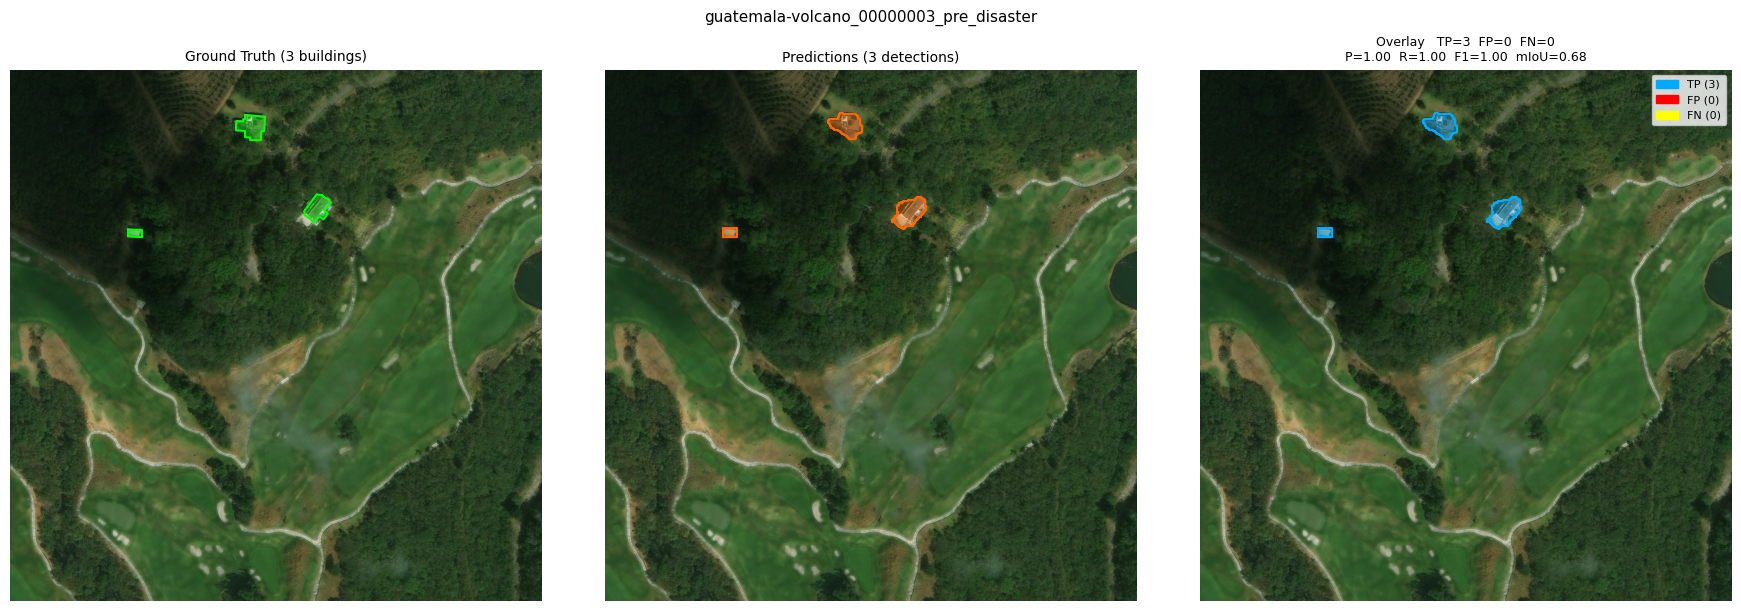

(ipywidgets active — use the dropdown to switch images)


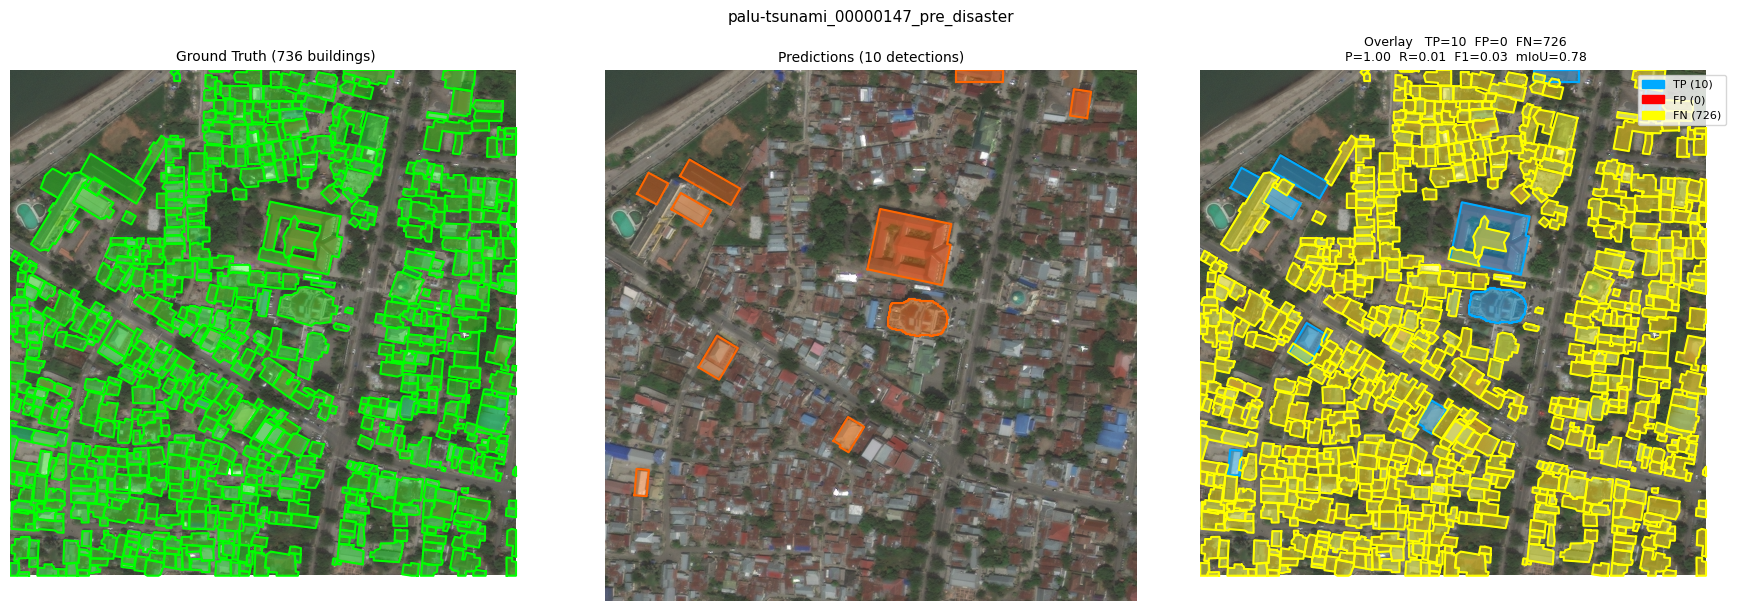

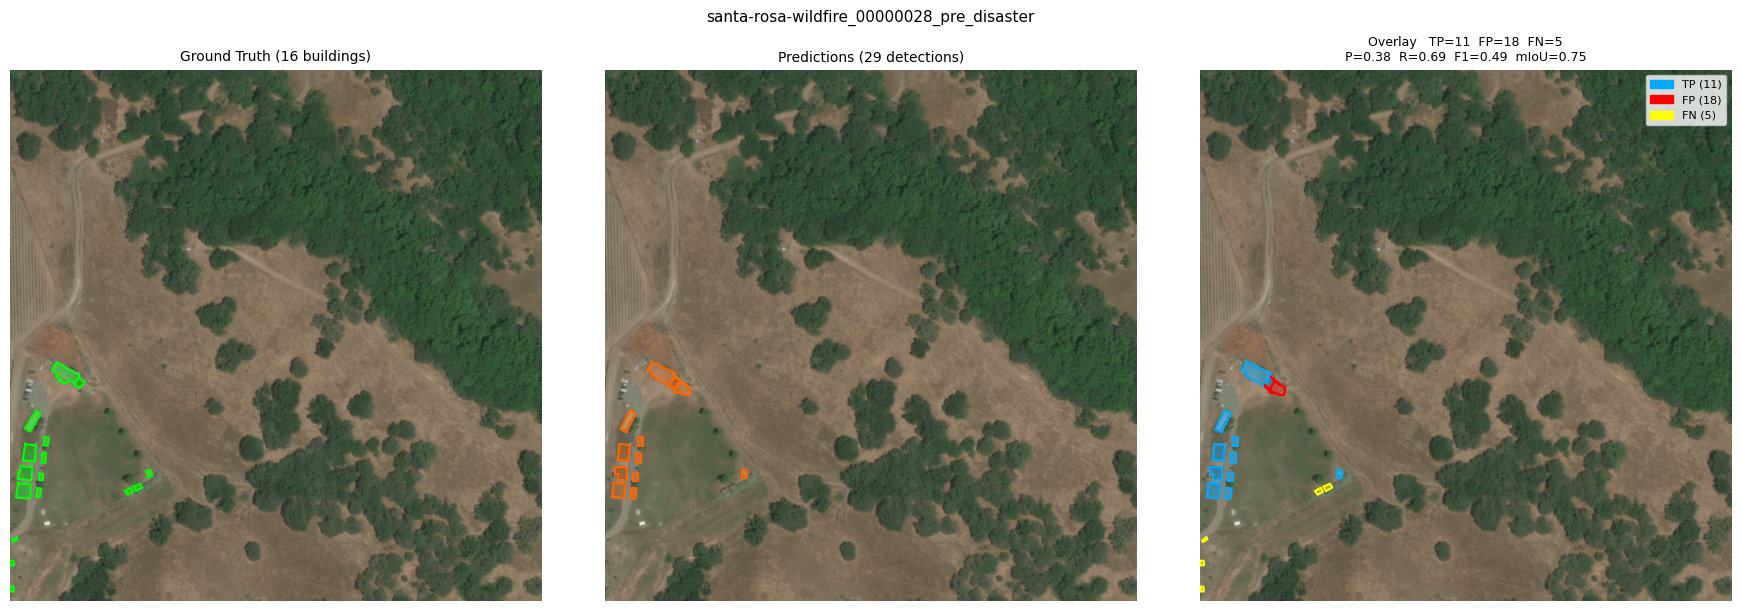

In [8]:
# ── Cell 8: Image selector ────────────────────────────────────────────────────
# Uses ipywidgets if available, otherwise falls back to a simple variable.

if not paired_stems:
    print("No paired images available for visualization.")
else:
    try:
        import ipywidgets as widgets

        selector = widgets.Dropdown(
            options=paired_stems,
            value=paired_stems[0],
            description='Image:',
            layout=widgets.Layout(width='70%'),
        )

        def _on_select(change):
            stem = change['new']
            gt_i = parse_gt(gt_index[stem])
            pr_i, _ = parse_pred(pred_index[stem])
            mr = match_predictions(pr_i, gt_i, IOU_THRESHOLD)
            m  = compute_metrics(mr['tp'], mr['fp'], mr['fn'], mr['iou_per_tp'])
            print(f"GT: {len(gt_i)}  Pred: {len(pr_i)}  "
                  f"TP={mr['tp']} FP={mr['fp']} FN={mr['fn']}  "
                  f"P={m['precision']:.2f} R={m['recall']:.2f} F1={m['f1']:.2f}")
            visualize_single(stem, pr_i, gt_i, mr, IOU_THRESHOLD)

        selector.observe(_on_select, names='value')
        display(selector)
        _on_select({'new': paired_stems[0]})  # show first image immediately
        print("(ipywidgets active — use the dropdown to switch images)")

    except ImportError:
        print("ipywidgets not available — using manual selection below.")
        print(f"Available stems: {paired_stems[:10]}")

Stem    : guatemala-volcano_00000003_pre_disaster
Format  : sam3_claude_new
GT      : 3 buildings
Pred    : 3 detections
TP=3  FP=0  FN=0  (IoU≥0.5)
Precision=1.000  Recall=1.000  F1=1.000  mean_IoU_TP=0.681
IoU values (TP): [0.562, 0.747, 0.736]


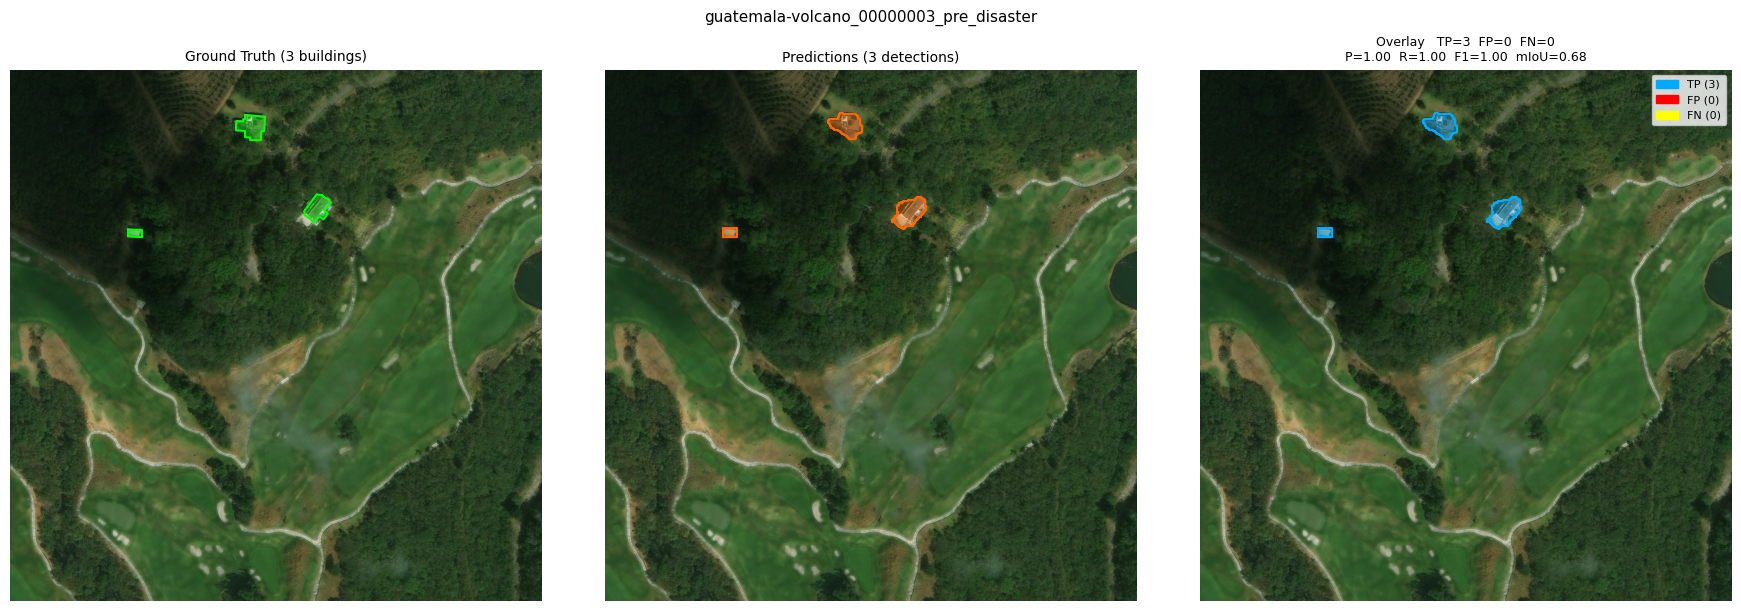

In [9]:
# ── Cell 9: Manual single-image visualization (edit stem here) ───────────────
# Use this cell if ipywidgets is unavailable, or to visualize any specific image.

SELECTED_STEM = paired_stems[0] if paired_stems else None

if SELECTED_STEM:
    gt_i  = parse_gt(gt_index[SELECTED_STEM])
    pr_i, fmt = parse_pred(pred_index[SELECTED_STEM])
    mr    = match_predictions(pr_i, gt_i, IOU_THRESHOLD)
    m     = compute_metrics(mr['tp'], mr['fp'], mr['fn'], mr['iou_per_tp'])

    print(f"Stem    : {SELECTED_STEM}")
    print(f"Format  : {fmt}")
    print(f"GT      : {len(gt_i)} buildings")
    print(f"Pred    : {len(pr_i)} detections")
    print(f"TP={mr['tp']}  FP={mr['fp']}  FN={mr['fn']}  (IoU≥{IOU_THRESHOLD})")
    print(f"Precision={m['precision']:.3f}  Recall={m['recall']:.3f}  "
          f"F1={m['f1']:.3f}  mean_IoU_TP={m['mean_iou_tp']:.3f}")
    if mr['iou_per_tp']:
        print(f"IoU values (TP): {[round(v,3) for v in mr['iou_per_tp']]}")

    visualize_single(SELECTED_STEM, pr_i, gt_i, mr, IOU_THRESHOLD)
else:
    print("No paired images available.")

In [10]:
# ── Cell 10: Batch evaluation ─────────────────────────────────────────────────
# Evaluates ALL paired images and collects per-image stats.
# For a quick sanity check, set MAX_EVAL_IMAGES to a small number (e.g. 50).

MAX_EVAL_IMAGES = None   # None = evaluate all paired images

if not paired_stems:
    print("No paired images — skipping batch evaluation.")
    batch_records = []
else:
    stems_to_eval = paired_stems[:MAX_EVAL_IMAGES] if MAX_EVAL_IMAGES else paired_stems
    print(f"Evaluating {len(stems_to_eval)} paired images at IoU≥{IOU_THRESHOLD} ...")
    batch_records = []

    for stem in tqdm(stems_to_eval, desc="Evaluating"):
        gt_i  = parse_gt(gt_index[stem])
        pr_i, _ = parse_pred(pred_index[stem])

        if len(gt_i) == 0 and len(pr_i) == 0:
            # Both empty — skip to avoid trivially-perfect precision
            continue

        mr = match_predictions(pr_i, gt_i, IOU_THRESHOLD)
        m  = compute_metrics(mr['tp'], mr['fp'], mr['fn'], mr['iou_per_tp'])

        batch_records.append({
            'stem': stem,
            'n_gt': len(gt_i),
            'n_pred': len(pr_i),
            'tp': mr['tp'],
            'fp': mr['fp'],
            'fn': mr['fn'],
            'precision': round(m['precision'], 3),
            'recall': round(m['recall'], 3),
            'f1': round(m['f1'], 3),
            'mean_iou_tp': round(m['mean_iou_tp'], 3),
        })

    print(f"Done. Evaluated {len(batch_records)} images.")

Evaluating 933 paired images at IoU≥0.5 ...


Evaluating:   0%|          | 0/933 [00:00<?, ?it/s]

Done. Evaluated 753 images.


In [11]:
# ── Cell 11: Per-image results table ─────────────────────────────────────────

if batch_records:
    df = pd.DataFrame(batch_records)

    # Aggregate totals (micro-average: sum TP/FP/FN across all images)
    total_tp = df['tp'].sum()
    total_fp = df['fp'].sum()
    total_fn = df['fn'].sum()
    agg = compute_metrics(total_tp, total_fp, total_fn, [])
    macro_f1   = df['f1'].mean()
    macro_miou = df['mean_iou_tp'].mean()

    print("=" * 60)
    print("AGGREGATE RESULTS (micro-average over all images)")
    print("=" * 60)
    print(f"  Images evaluated : {len(df)}")
    print(f"  Total GT         : {df['n_gt'].sum()}")
    print(f"  Total Pred       : {df['n_pred'].sum()}")
    print(f"  Total TP         : {total_tp}")
    print(f"  Total FP         : {total_fp}")
    print(f"  Total FN         : {total_fn}")
    print(f"  Precision        : {agg['precision']:.4f}")
    print(f"  Recall           : {agg['recall']:.4f}")
    print(f"  F1 (micro)       : {agg['f1']:.4f}")
    print(f"  F1 (macro)       : {macro_f1:.4f}")
    print(f"  Mean IoU (TP)    : {macro_miou:.4f}")
    print()

    # Per-image table
    pd.set_option('display.max_rows', 50)
    pd.set_option('display.float_format', '{:.3f}'.format)
    display(df.sort_values('f1', ascending=False).reset_index(drop=True))
else:
    print("No batch records — run Cell 10 first.")

AGGREGATE RESULTS (micro-average over all images)
  Images evaluated : 753
  Total GT         : 54862
  Total Pred       : 22824
  Total TP         : 15567
  Total FP         : 7257
  Total FN         : 39295
  Precision        : 0.6820
  Recall           : 0.2837
  F1 (micro)       : 0.4008
  F1 (macro)       : 0.4893
  Mean IoU (TP)    : 0.6544



,stem,n_gt,n_pred,tp,fp,fn,precision,recall,f1,mean_iou_tp
0,guatemala-volcano_00000003_pre_disaster,3,3,3,0,0,1.000,1.000,1.000,0.681
1,midwest-flooding_00000232_pre_disaster,6,6,6,0,0,1.000,1.000,1.000,0.755
2,hurricane-florence_00000167_pre_disaster,4,4,4,0,0,1.000,1.000,1.000,0.768
3,midwest-flooding_00000363_pre_disaster,1,1,1,0,0,1.000,1.000,1.000,0.886
4,midwest-flooding_00000006_pre_disaster,5,5,5,0,0,1.000,1.000,1.000,0.625
...,...,...,...,...,...,...,...,...,...,...
748,socal-fire_00000963_pre_disaster,5,0,0,0,5,0.000,0.000,0.000,0.000
749,socal-fire_00001031_pre_disaster,8,0,0,0,8,0.000,0.000,0.000,0.000
750,socal-fire_00001046_pre_disaster,2,0,0,0,2,0.000,0.000,0.000,0.000
751,socal-fire_00001114_pre_disaster,2,0,0,0,2,0.000,0.000,0.000,0.000


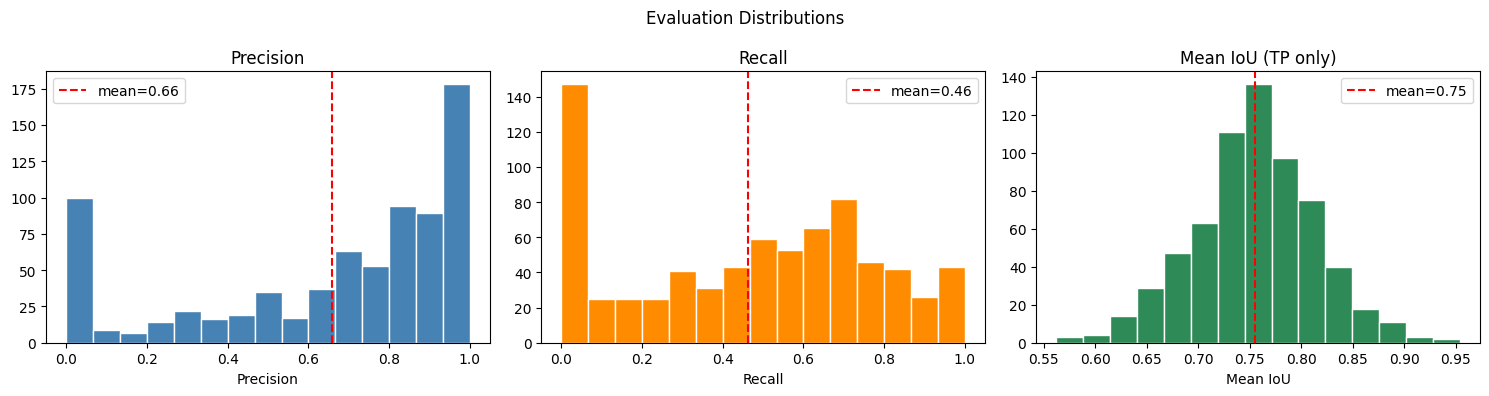

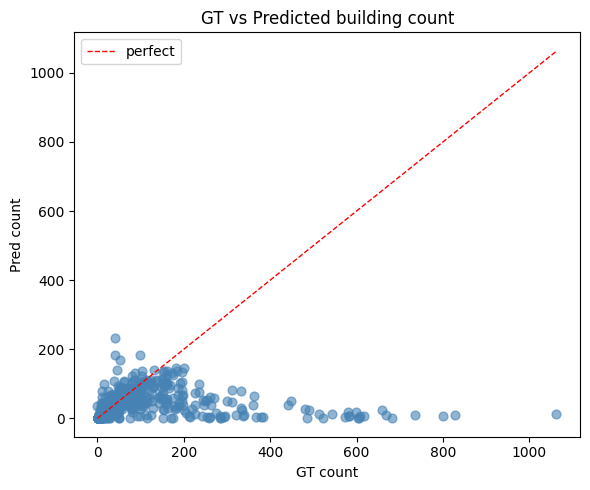

In [12]:
# ── Cell 12: Distribution plots ───────────────────────────────────────────────

if batch_records and len(batch_records) >= 2:
    df = pd.DataFrame(batch_records)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Evaluation Distributions", fontsize=12)

    axes[0].hist(df['precision'], bins=15, color='steelblue', edgecolor='white')
    axes[0].axvline(df['precision'].mean(), color='red', linestyle='--', label=f'mean={df["precision"].mean():.2f}')
    axes[0].set_title('Precision'); axes[0].set_xlabel('Precision'); axes[0].legend()

    axes[1].hist(df['recall'], bins=15, color='darkorange', edgecolor='white')
    axes[1].axvline(df['recall'].mean(), color='red', linestyle='--', label=f'mean={df["recall"].mean():.2f}')
    axes[1].set_title('Recall'); axes[1].set_xlabel('Recall'); axes[1].legend()

    axes[2].hist(df['mean_iou_tp'].replace(0, float('nan')).dropna(), bins=15, color='seagreen', edgecolor='white')
    non_zero_miou = df['mean_iou_tp'][df['mean_iou_tp'] > 0]
    if len(non_zero_miou) > 0:
        axes[2].axvline(non_zero_miou.mean(), color='red', linestyle='--', label=f'mean={non_zero_miou.mean():.2f}')
        axes[2].legend()
    axes[2].set_title('Mean IoU (TP only)'); axes[2].set_xlabel('Mean IoU')

    plt.tight_layout()
    plt.show()

    # GT vs Pred count scatter
    fig2, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(df['n_gt'], df['n_pred'], alpha=0.6, color='steelblue', s=40)
    lim = max(df['n_gt'].max(), df['n_pred'].max()) + 2
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='perfect')
    ax.set_xlabel('GT count'); ax.set_ylabel('Pred count')
    ax.set_title('GT vs Predicted building count')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Need ≥2 evaluated images for distribution plots.")


── WORST: guatemala-volcano_00000005_pre_disaster  F1=0.000 ──


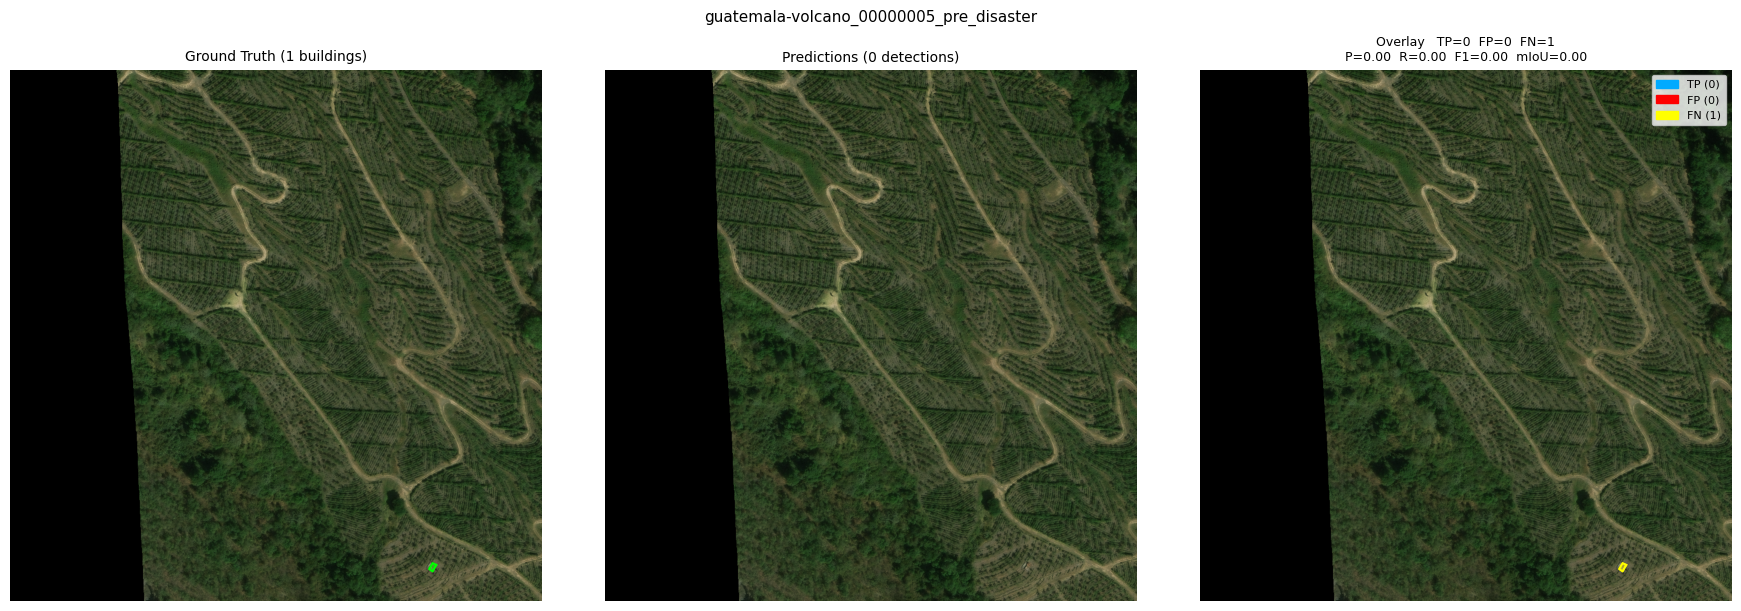


── WORST: guatemala-volcano_00000011_pre_disaster  F1=0.000 ──


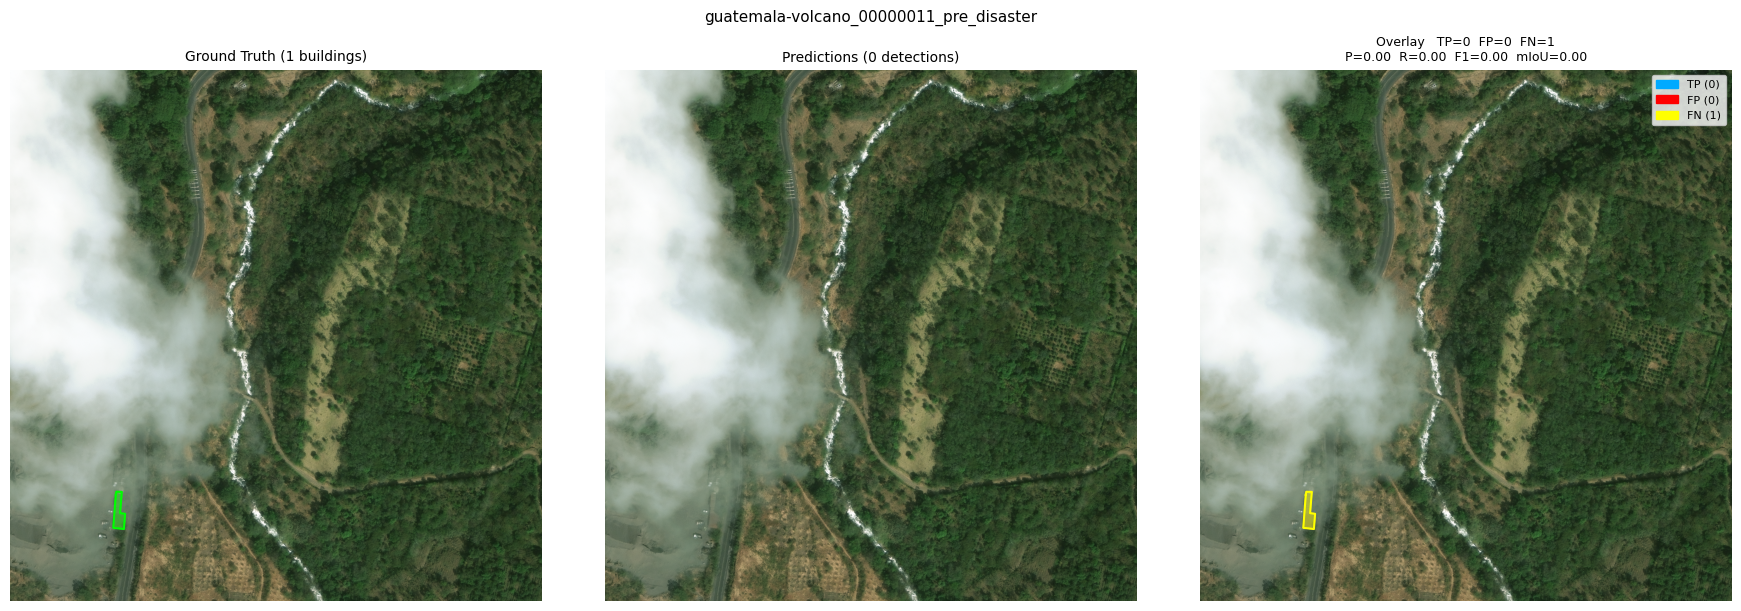


── BEST: guatemala-volcano_00000003_pre_disaster  F1=1.000 ──


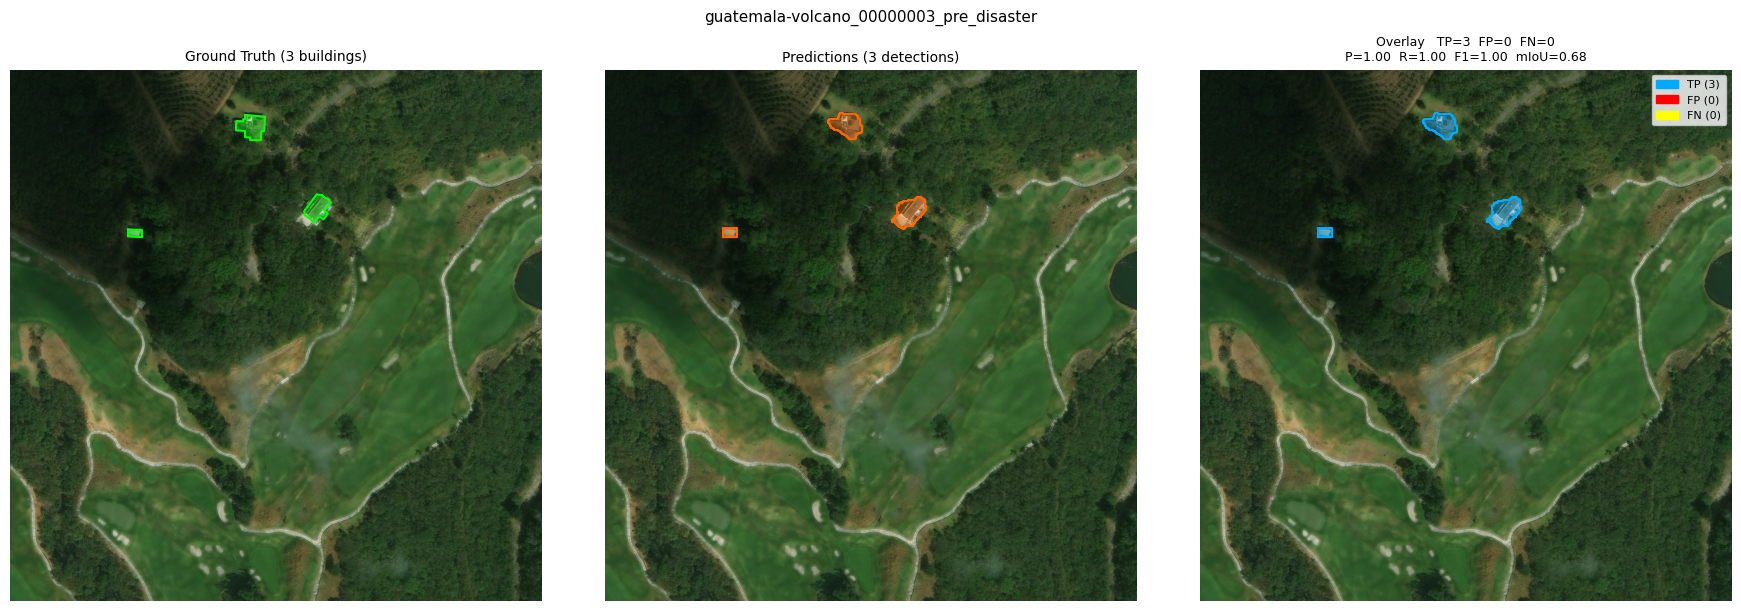


── BEST: hurricane-florence_00000116_pre_disaster  F1=1.000 ──


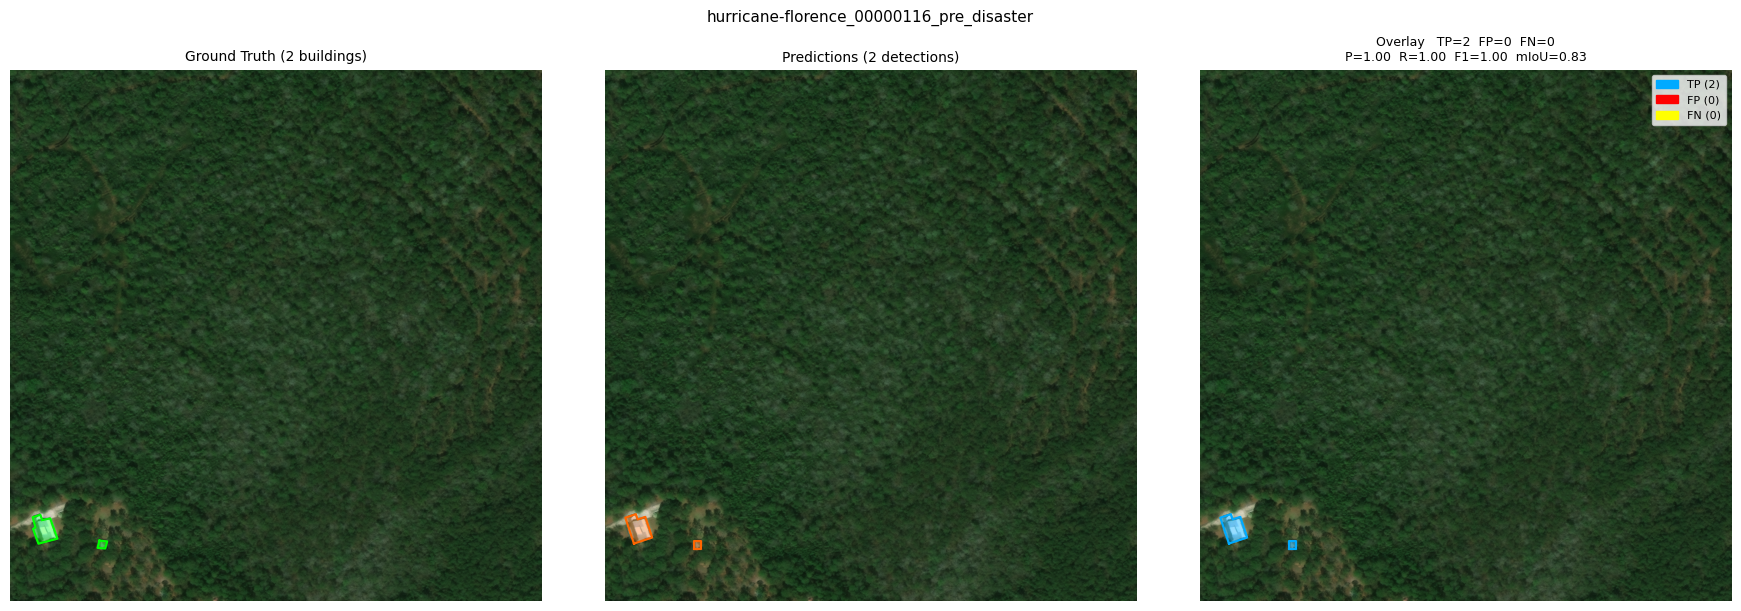

In [13]:
# ── Cell 13: Browse worst/best images ────────────────────────────────────────
# Visualize the N worst and N best images by F1 score.

N_SHOW = 2  # number of images to show at each end

if batch_records and len(batch_records) >= 2:
    df = pd.DataFrame(batch_records)
    worst = df.nsmallest(N_SHOW, 'f1')
    best  = df.nlargest(N_SHOW, 'f1')

    for label, subset in [("WORST", worst), ("BEST", best)]:
        for _, row in subset.iterrows():
            stem = row['stem']
            print(f"\n── {label}: {stem}  F1={row['f1']:.3f} ──")
            gt_i = parse_gt(gt_index[stem])
            pr_i, _ = parse_pred(pred_index[stem])
            mr = match_predictions(pr_i, gt_i, IOU_THRESHOLD)
            visualize_single(stem, pr_i, gt_i, mr, IOU_THRESHOLD)
else:
    print("Not enough evaluated images to show worst/best.")